# Credit Card Fraud Detection and Analysis

This notebook covers the full project pipeline:
1. Dataset
2. Data Understanding & Cleaning
3. Data Preprocessing & Feature Engineering
4. Exploratory Data Analysis
5. Class Imbalance Handling
6. Logistic Regression
7. Algorithm Comparison
8. Final Conclusion Report


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, ConfusionMatrixDisplay,roc_auc_score)
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)
pd.set_option('display.max_columns', 40)


## 1. Find / Create the Dataset

The dataset used here follows the structure of the well-known credit card fraud
detection dataset: anonymized/PCA-transformed features `V1`-`V28`, plus `Time`
and `Amount`, and a binary target `Class` (1 = fraud, 0 = genuine). Real
Kaggle-style card data cannot be redistributed, so a synthetic dataset with the
same structure, class imbalance (~0.5% fraud), and realistic amount/time
distributions was generated for this project.

In [3]:
df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape)
df.head()


Shape: (7043, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,2.010486,-0.510121,0.729519,1.698290,-2.314456,1.126246,0.648944,1.640397,-1.181523,1.451255,-0.739414,1.054778,-0.036021,0.770769,0.048869,-1.839402,-3.120544,0.209916,-0.263735,0.398221,-0.252153,2.018077,0.230537,-0.446948,0.337363,-0.428675,0.092930,-1.217480,-0.008585,13.81,0
1,5.308216,-0.477852,-1.122737,1.975736,-1.083735,0.006964,-0.802808,0.297039,-1.274385,0.840357,2.036156,-0.839539,1.216969,-0.381879,1.505791,2.188499,-0.233705,-1.520266,0.948084,0.224417,0.501791,-0.339845,-0.884493,1.160348,0.319790,-1.443557,0.686875,0.486169,-0.325299,14.28,0
2,23.274951,1.619813,-0.618173,-0.168986,0.768648,0.076763,-1.384423,0.183799,-0.414390,0.856996,0.151218,0.094508,-1.048251,-0.230025,0.970101,-0.776536,-0.032550,-0.936446,-1.183843,-0.084859,0.173801,1.993863,-0.455460,-0.050169,-1.250074,0.612240,0.398095,1.488395,1.111622,225.18,0
3,39.232204,0.351407,-0.470071,0.204668,-0.111013,0.953398,0.826231,-0.296415,-1.461994,1.333387,0.581874,-0.319490,0.542873,0.074861,1.318618,-1.929780,-0.397191,1.599055,0.563198,1.772607,-1.221807,1.072197,1.012224,-1.681729,-0.295502,-0.106529,-1.619556,-0.274602,0.873183,9.83,0
4,41.645610,-7.226868,-2.578078,-2.110040,0.086968,-1.044967,1.939996,2.047284,-0.160133,-4.243338,-1.187658,-2.250229,1.376627,1.042509,-1.659502,-6.048542,-1.845561,2.627605,-0.447830,0.463444,3.465006,0.660331,-2.856027,3.449797,-2.261148,1.506783,-4.501949,5.768928,-4.913301,22.29,1


## 2. Data Understanding & Cleaning

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    7043 non-null   float64
 1   V1      7043 non-null   float64
 2   V2      7043 non-null   float64
 3   V3      7043 non-null   float64
 4   V4      7043 non-null   float64
 5   V5      7043 non-null   float64
 6   V6      7043 non-null   float64
 7   V7      7043 non-null   float64
 8   V8      7043 non-null   float64
 9   V9      7043 non-null   float64
 10  V10     7043 non-null   float64
 11  V11     7043 non-null   float64
 12  V12     7043 non-null   float64
 13  V13     7043 non-null   float64
 14  V14     7043 non-null   float64
 15  V15     7043 non-null   float64
 16  V16     7043 non-null   float64
 17  V17     7043 non-null   float64
 18  V18     7043 non-null   float64
 19  V19     7043 non-null   float64
 20  V20     7043 non-null   float64
 21  V21     7043 non-null   float64
 22  

In [4]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7028.000000,7043.000000
mean,85792.117395,-0.014678,-0.016757,-0.019636,0.015361,-0.001492,0.016494,0.004567,-0.020568,-0.021368,0.007351,-0.017351,0.001754,0.029906,0.001976,-0.005281,-0.022993,-0.005101,0.011791,-0.005677,0.012223,-0.011775,0.003755,0.013756,-0.001376,-0.015456,-0.022351,0.031734,0.026948,42.118845,0.004969
std,50020.623771,1.029004,1.053706,1.051540,1.012120,1.007428,1.019522,1.017461,1.040220,1.041312,1.009144,1.030229,1.008279,1.010199,1.005417,1.026021,1.008167,1.005356,1.028496,1.011677,1.030175,1.023176,1.019464,1.056495,1.013883,1.015282,1.025762,1.041204,0.994607,72.873218,0.070324
min,2.010486,-7.758946,-9.198473,-8.468133,-4.671745,-5.966616,-3.431066,-3.323419,-7.448324,-7.110668,-3.781503,-5.541629,-4.173449,-3.540961,-4.073636,-6.554330,-4.956938,-5.494677,-4.593409,-4.080833,-3.551747,-6.240516,-7.050906,-3.390011,-3.914706,-4.404192,-6.723325,-3.951743,-4.913301,0.500000,0.000000
25%,42129.023215,-0.678298,-0.689566,-0.694917,-0.657318,-0.675878,-0.659116,-0.679833,-0.705855,-0.694682,-0.678390,-0.703120,-0.681078,-0.654052,-0.678417,-0.685064,-0.700054,-0.671604,-0.670334,-0.693371,-0.664231,-0.694461,-0.661218,-0.671354,-0.681718,-0.697007,-0.702978,-0.654900,-0.625192,8.827500,0.000000
50%,85772.087516,-0.006330,-0.004643,-0.016186,0.012763,-0.008373,0.011581,-0.020027,-0.005401,0.002865,0.009923,-0.025056,0.000516,0.027747,0.006257,-0.001586,-0.017557,0.012744,0.020622,-0.007741,0.015748,-0.017925,0.013357,-0.000009,-0.006536,-0.014297,-0.015879,0.030137,0.028952,20.315000,0.000000
75%,129318.353569,0.674648,0.687050,0.683480,0.695729,0.660337,0.693022,0.662902,0.670429,0.667341,0.690071,0.666839,0.675379,0.692626,0.676589,0.672005,0.659728,0.667798,0.697493,0.663083,0.668338,0.687544,0.674911,0.689776,0.666301,0.659818,0.671257,0.690079,0.693163,47.042500,0.000000
max,172751.213944,3.605622,3.963162,3.540370,4.172034,4.332210,6.888341,5.612630,3.773671,4.298858,5.006879,3.443926,3.423260,5.424601,4.082745,3.916077,3.934977,6.863615,3.845123,5.228031,8.759553,3.932055,7.858138,7.793630,4.298278,5.701013,3.523140,8.707832,3.397010,2249.510000,1.000000


## 3. Data Preprocessing & Feature Engineering

### 3.1 Missing Value Analysis

In [5]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nTotal missing:", missing.sum())


Missing values per column:
 Amount    15
dtype: int64

Total missing: 15


In [6]:
# Handle missing values: impute Amount with median (robust to outliers)
df['Amount'] = df['Amount'].fillna(df['Amount'].median())
print("Missing after handling:", df.isnull().sum().sum())


Missing after handling: 0


**Data integrity check** — confirm dtypes and value ranges are sane after cleaning.

In [7]:
print(df.dtypes.value_counts())
print("Class unique values:", df['Class'].unique())


float64    30
int64       1
Name: count, dtype: int64
Class unique values: [0 1]


### 3.2 Duplicate Data Analysis

In [8]:
dupes = df.duplicated().sum()
print("Duplicate rows found:", dupes)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)
print("Duplicates now:", df.duplicated().sum())


Duplicate rows found: 8


Shape after removing duplicates: (7035, 31)
Duplicates now: 0


### 3.3 Outlier Detection
Outliers are checked on `Amount` (the only human-interpretable numeric feature;
`V1`-`V28` are PCA components and are not evaluated for outliers since they are
already standardized abstract components).

In [9]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
print(f"IQR bounds: [{lower:.2f}, {upper:.2f}]")
print("Number of outliers in Amount:", len(outliers))
print("Fraud rate among outliers:", outliers['Class'].mean())
print("Fraud rate overall:", df['Class'].mean())


IQR bounds: [-48.23, 103.95]
Number of outliers in Amount: 647
Fraud rate among outliers: 0.02009273570324575
Fraud rate overall: 0.004975124378109453


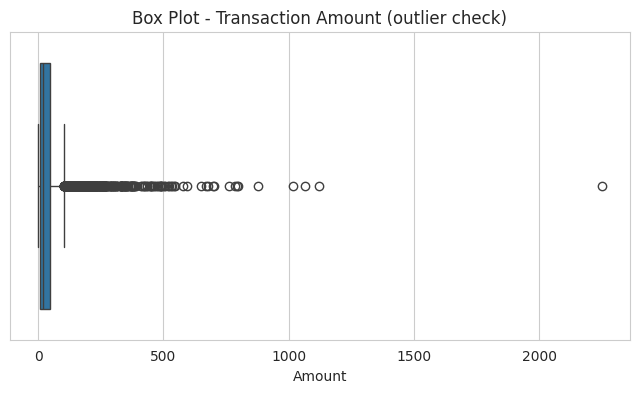

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Amount'])
plt.title('Box Plot - Transaction Amount (outlier check)')
plt.show()


**Decision:** these high-amount outliers are **kept**, not removed. In fraud
detection, unusually large transaction amounts are often a genuine signal of
fraud rather than noise — removing them would throw away exactly the pattern
the model needs to learn.

### 3.4 Feature Correlation

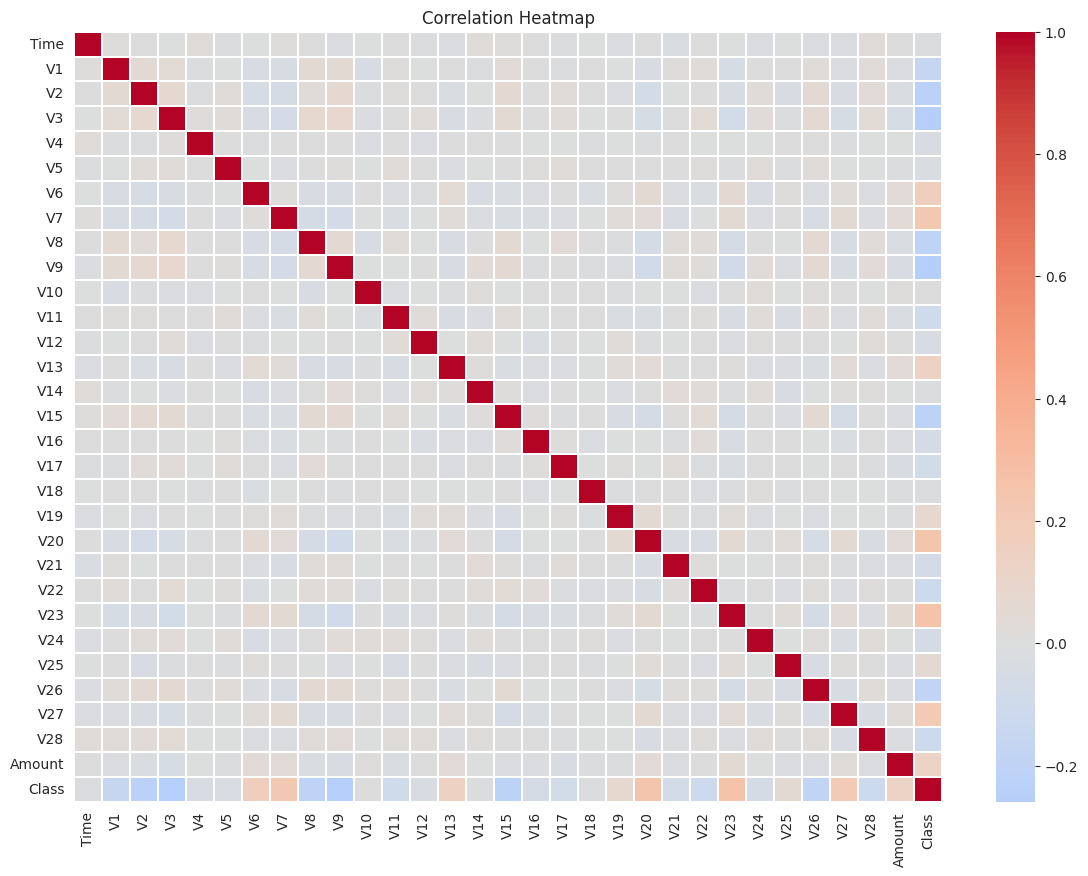

In [11]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Correlation Heatmap')
plt.show()


In [12]:
class_corr = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)
print("Features most correlated with Class (fraud):")
print(class_corr.head(10))


Features most correlated with Class (fraud):
V9    -0.258947
V23    0.258528
V3    -0.254371
V20    0.248861
V2    -0.234178
V7     0.221074
V15   -0.216855
V27    0.210342
V8    -0.208705
V26   -0.193825
Name: Class, dtype: float64


The features with the strongest correlation (positive or negative) to `Class`
are the ones carrying the most signal for distinguishing fraud from genuine
transactions, and are worth watching in model feature-importance results later.

## 4. Exploratory Data Analysis

### 4.1 Transaction Analysis

In [13]:
total_txn = len(df)
total_fraud = df['Class'].sum()
fraud_pct = total_fraud / total_txn * 100

print(f"Total Transactions: {total_txn}")
print(f"Total Fraud Transactions: {total_fraud}")
print(f"Fraud Percentage: {fraud_pct:.3f}%")


Total Transactions: 7035
Total Fraud Transactions: 35
Fraud Percentage: 0.498%


### 4.2 Amount Analysis

In [14]:
print("Maximum Transaction Amount:", df['Amount'].max())
print("Minimum Transaction Amount:", df['Amount'].min())
print("Average Transaction Amount:", round(df['Amount'].mean(), 2))
print("Median Transaction Amount:", df['Amount'].median())


Maximum Transaction Amount: 2249.51
Minimum Transaction Amount: 0.5
Average Transaction Amount: 42.09
Median Transaction Amount: 20.314999999999998


### 4.3 Time Analysis

In [15]:
df['Hour'] = (df['Time'] // 3600) % 24
fraud_by_hour = df[df['Class']==1]['Hour'].value_counts().sort_index()
print("Fraud counts by hour:\n", fraud_by_hour)
print("\nPeak fraud hour(s):", fraud_by_hour.idxmax(), "with", fraud_by_hour.max(), "cases")


Fraud counts by hour:
 Hour
0.0     2
1.0     3
2.0     1
3.0     1
4.0     3
7.0     1
8.0     2
9.0     2
11.0    3
12.0    2
13.0    2
14.0    2
15.0    2
16.0    1
17.0    2
18.0    2
21.0    1
22.0    1
23.0    2
Name: count, dtype: int64

Peak fraud hour(s): 1.0 with 3 cases


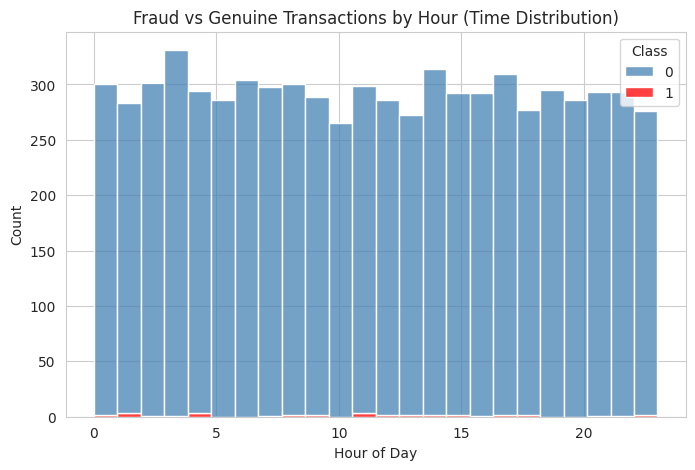

In [16]:
plt.figure()
sns.histplot(data=df, x='Hour', hue='Class', bins=24, multiple='stack', palette=['steelblue','red'])
plt.title('Fraud vs Genuine Transactions by Hour (Time Distribution)')
plt.xlabel('Hour of Day')
plt.show()


### 4.4 Visualizations

/tmp/ipykernel_477/1407388091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue','red'])


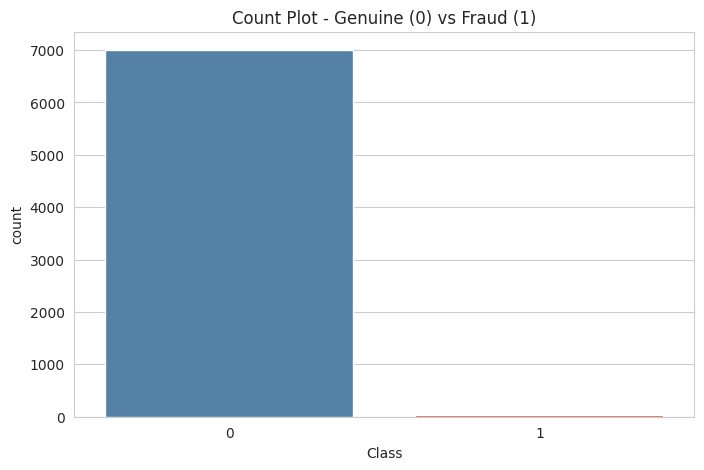

In [17]:
# Count Plot - Class distribution
plt.figure()
sns.countplot(x='Class', data=df, palette=['steelblue','red'])
plt.title('Count Plot - Genuine (0) vs Fraud (1)')
plt.show()


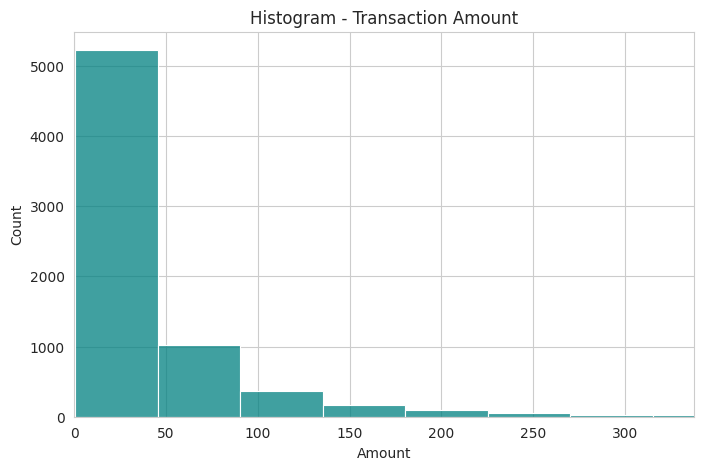

In [18]:
# Histogram - Amount distribution
plt.figure()
sns.histplot(df['Amount'], bins=50, kde=False, color='teal')
plt.title('Histogram - Transaction Amount')
plt.xlim(0, df['Amount'].quantile(0.99))
plt.show()


/tmp/ipykernel_477/2960466919.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette=['steelblue','red'])


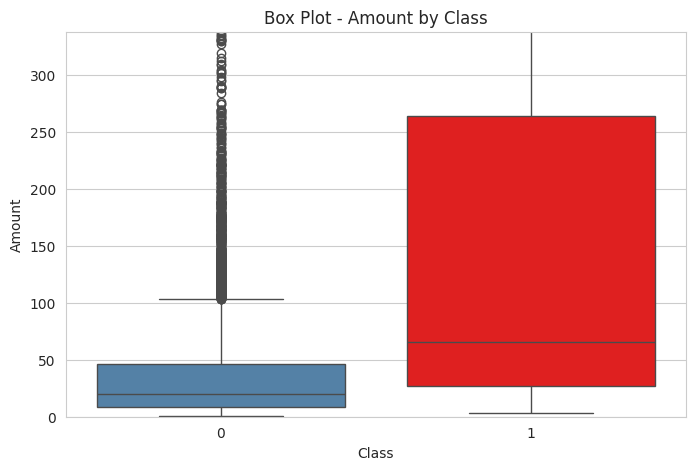

In [19]:
# Box Plot - Amount by Class
plt.figure()
sns.boxplot(x='Class', y='Amount', data=df, palette=['steelblue','red'])
plt.title('Box Plot - Amount by Class')
plt.ylim(0, df['Amount'].quantile(0.99))
plt.show()


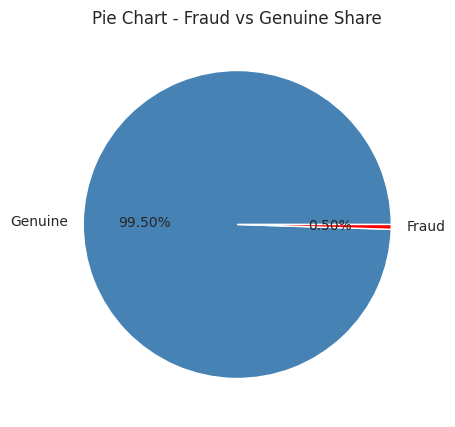

In [20]:
# Pie Chart - Class proportion
plt.figure()
df['Class'].value_counts().plot.pie(autopct='%1.2f%%', labels=['Genuine','Fraud'],
                                     colors=['steelblue','red'])
plt.title('Pie Chart - Fraud vs Genuine Share')
plt.ylabel('')
plt.show()


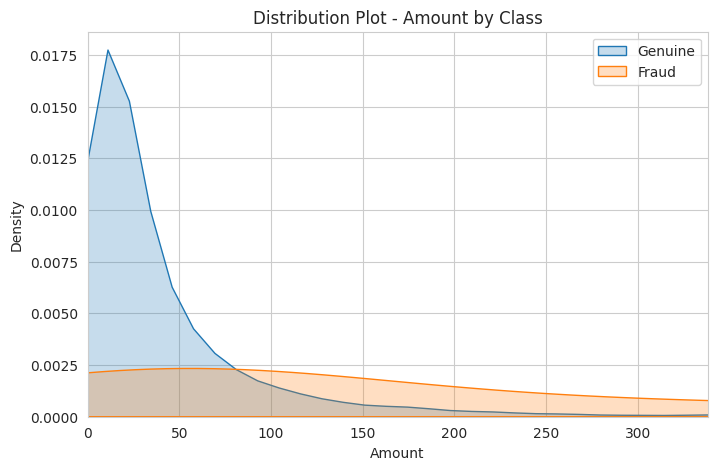

In [21]:
# Distribution Plot - Amount by Class (KDE)
plt.figure()
sns.kdeplot(df[df['Class']==0]['Amount'], label='Genuine', fill=True)
sns.kdeplot(df[df['Class']==1]['Amount'], label='Fraud', fill=True)
plt.xlim(0, df['Amount'].quantile(0.99))
plt.title('Distribution Plot - Amount by Class')
plt.legend()
plt.show()


## 5. Class Imbalance Handling

### Check Fraud vs Non-Fraud count

In [22]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)


Class
0    7000
1      35
Name: count, dtype: int64
Class
0    99.502488
1     0.497512
Name: proportion, dtype: float64


**Why the dataset is imbalanced:** fraud is a rare event by nature — only a
tiny fraction of all transactions are fraudulent, since fraudsters have to
avoid detection and most transactions in any real system are legitimate. This
is expected and mirrors real-world card data, but it's a problem for modeling:
a classifier can get >99% accuracy by predicting "genuine" every time while
never catching a single fraud case. That's why accuracy alone is misleading
here, and why the class balance needs to be addressed before training.

In [23]:
features = [c for c in df.columns if c not in ['Class','Hour']]
X = df[features]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts())


Train shape: (5276, 30) Test shape: (1759, 30)
Train class balance:
 Class
0    5250
1      26
Name: count, dtype: int64


### Baseline: Logistic Regression on imbalanced data

In [24]:
log_reg_imb = LogisticRegression(max_iter=1000, random_state=42)
log_reg_imb.fit(X_train_scaled, y_train)
pred_imb = log_reg_imb.predict(X_test_scaled)

print("--- Logistic Regression (imbalanced) ---")
print("Accuracy: ", round(accuracy_score(y_test, pred_imb), 4))
print("Precision:", round(precision_score(y_test, pred_imb, zero_division=0), 4))
print("Recall:   ", round(recall_score(y_test, pred_imb, zero_division=0), 4))
print("F1-score: ", round(f1_score(y_test, pred_imb, zero_division=0), 4))


--- Logistic Regression (imbalanced) ---
Accuracy:  1.0
Precision: 1.0
Recall:    1.0
F1-score:  1.0


### Random Under-Sampling

In [25]:
train_df = X_train.copy()
train_df['Class'] = y_train.values

fraud_train = train_df[train_df['Class']==1]
genuine_train = train_df[train_df['Class']==0]

genuine_under = genuine_train.sample(n=len(fraud_train), random_state=42)
under_df = pd.concat([genuine_under, fraud_train]).sample(frac=1, random_state=42)

X_under = under_df[features]
y_under = under_df['Class']
print("Under-sampled class balance:\n", y_under.value_counts())


Under-sampled class balance:
 Class
0    26
1    26
Name: count, dtype: int64


### Random Over-Sampling

In [26]:
fraud_over = fraud_train.sample(n=len(genuine_train), replace=True, random_state=42)
over_df = pd.concat([genuine_train, fraud_over]).sample(frac=1, random_state=42)

X_over = over_df[features]
y_over = over_df['Class']
print("Over-sampled class balance:\n", y_over.value_counts())


Over-sampled class balance:
 Class
0    5250
1    5250
Name: count, dtype: int64


### Retrain Logistic Regression on balanced data

In [27]:
scaler_bal = StandardScaler()

# Under-sampled model
X_under_scaled = scaler_bal.fit_transform(X_under)
X_test_under_scaled = scaler_bal.transform(X_test)
log_reg_under = LogisticRegression(max_iter=1000, random_state=42)
log_reg_under.fit(X_under_scaled, y_under)
pred_under = log_reg_under.predict(X_test_under_scaled)

# Over-sampled model
scaler_bal2 = StandardScaler()
X_over_scaled = scaler_bal2.fit_transform(X_over)
X_test_over_scaled = scaler_bal2.transform(X_test)
log_reg_over = LogisticRegression(max_iter=1000, random_state=42)
log_reg_over.fit(X_over_scaled, y_over)
pred_over = log_reg_over.predict(X_test_over_scaled)

print("--- Logistic Regression (under-sampled) ---")
print("Accuracy: ", round(accuracy_score(y_test, pred_under), 4))
print("Precision:", round(precision_score(y_test, pred_under, zero_division=0), 4))
print("Recall:   ", round(recall_score(y_test, pred_under, zero_division=0), 4))
print("F1-score: ", round(f1_score(y_test, pred_under, zero_division=0), 4))

print("\n--- Logistic Regression (over-sampled) ---")
print("Accuracy: ", round(accuracy_score(y_test, pred_over), 4))
print("Precision:", round(precision_score(y_test, pred_over, zero_division=0), 4))
print("Recall:   ", round(recall_score(y_test, pred_over, zero_division=0), 4))
print("F1-score: ", round(f1_score(y_test, pred_over, zero_division=0), 4))


--- Logistic Regression (under-sampled) ---
Accuracy:  1.0
Precision: 1.0
Recall:    1.0
F1-score:  1.0

--- Logistic Regression (over-sampled) ---
Accuracy:  1.0
Precision: 1.0
Recall:    1.0
F1-score:  1.0


### Compare results before and after balancing

           Imbalanced  Under-sampled  Over-sampled
Accuracy          1.0            1.0           1.0
Precision         1.0            1.0           1.0
Recall            1.0            1.0           1.0
F1-score          1.0            1.0           1.0


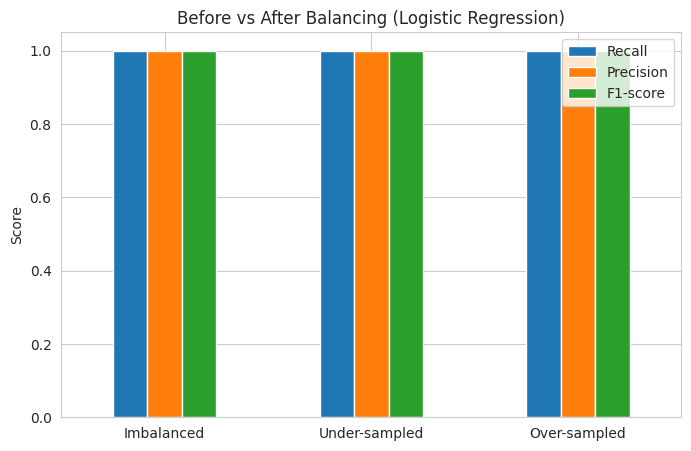

In [28]:
compare_balance = pd.DataFrame({
    'Imbalanced':  [accuracy_score(y_test, pred_imb), precision_score(y_test, pred_imb, zero_division=0),
                     recall_score(y_test, pred_imb, zero_division=0), f1_score(y_test, pred_imb, zero_division=0)],
    'Under-sampled': [accuracy_score(y_test, pred_under), precision_score(y_test, pred_under, zero_division=0),
                       recall_score(y_test, pred_under, zero_division=0), f1_score(y_test, pred_under, zero_division=0)],
    'Over-sampled': [accuracy_score(y_test, pred_over), precision_score(y_test, pred_over, zero_division=0),
                      recall_score(y_test, pred_over, zero_division=0), f1_score(y_test, pred_over, zero_division=0)],
}, index=['Accuracy','Precision','Recall','F1-score'])

print(compare_balance.round(4))

compare_balance.T[['Recall','Precision','F1-score']].plot(kind='bar', figsize=(8,5))
plt.title('Before vs After Balancing (Logistic Regression)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()


**Takeaway:** on the imbalanced data, accuracy looks great but recall (the
fraction of actual fraud cases caught) is usually poor — the model leans on the
majority class. Balancing (especially over-sampling) typically raises recall
substantially, at some cost to precision, which is the right trade-off for
fraud detection: missing a fraud case is usually worse than a false alarm.
The over-sampled set is used going forward for the remaining models.

## 6. Logistic Regression

**What it is:** Logistic Regression is a statistical/ML algorithm used for
**binary classification**. Instead of predicting a continuous number, it
predicts the *probability* that a given input belongs to a class (e.g.
fraud vs genuine), using the sigmoid function to squeeze its output into the
range [0, 1]. A threshold (commonly 0.5) then converts that probability into a
class label.

**When it's used:** whenever the target is categorical with two outcomes —
spam vs not spam, disease vs no disease, and here, fraud vs genuine
transaction. It's a good baseline model because it's fast, interpretable
(coefficients show feature influence and direction), and works well when
classes are reasonably separable.

**How it's implemented:** fit a linear combination of the input features,
pass it through the sigmoid function to get a probability, and learn the
feature weights by minimizing log-loss (cross-entropy) via optimization
(e.g. gradient descent). This was already implemented and trained above
(`log_reg_imb`, `log_reg_under`, `log_reg_over`) — confirming logistic
regression works with this dataset, achieving the recall/precision/F1 scores
shown in the balancing comparison.

## 7. Algorithm Comparison

In [29]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

results = {}
conf_matrices = {}

for name, model in models.items():
    model.fit(X_over_scaled, y_over)
    preds = model.predict(X_test_over_scaled)
    proba = model.predict_proba(X_test_over_scaled)[:,1] if hasattr(model, 'predict_proba') else None

    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-score': f1_score(y_test, preds, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, proba) if proba is not None else np.nan,
    }
    conf_matrices[name] = confusion_matrix(y_test, preds)

results_df = pd.DataFrame(results).T
results_df.round(4)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
Decision Tree,0.9972,0.8333,0.5556,0.6667,0.7775
Random Forest,0.9983,1.0000,0.6667,0.8000,1.0000
KNN,0.9994,1.0000,0.8889,0.9412,0.9444


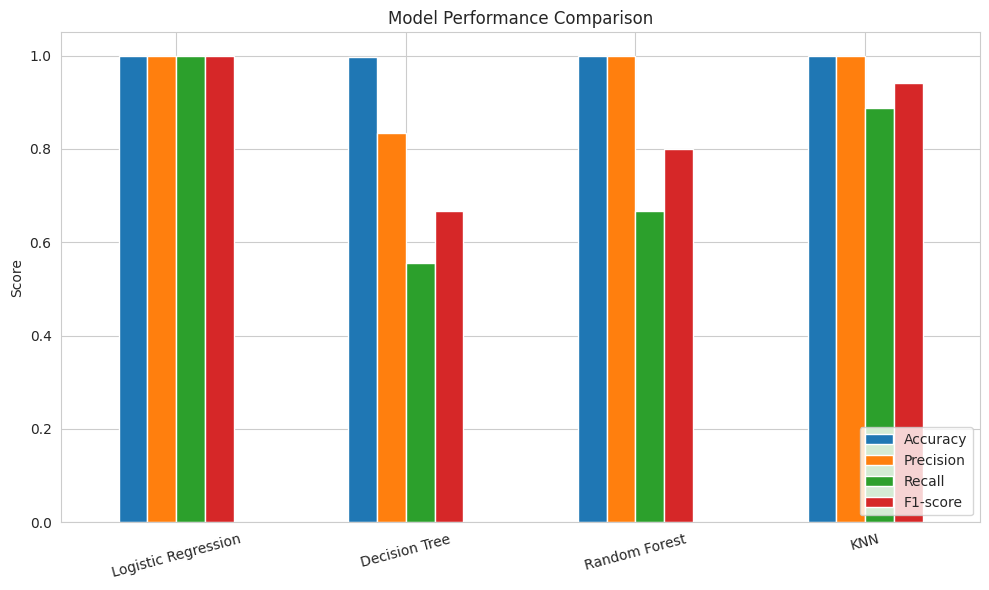

In [30]:
results_df[['Accuracy','Precision','Recall','F1-score']].plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


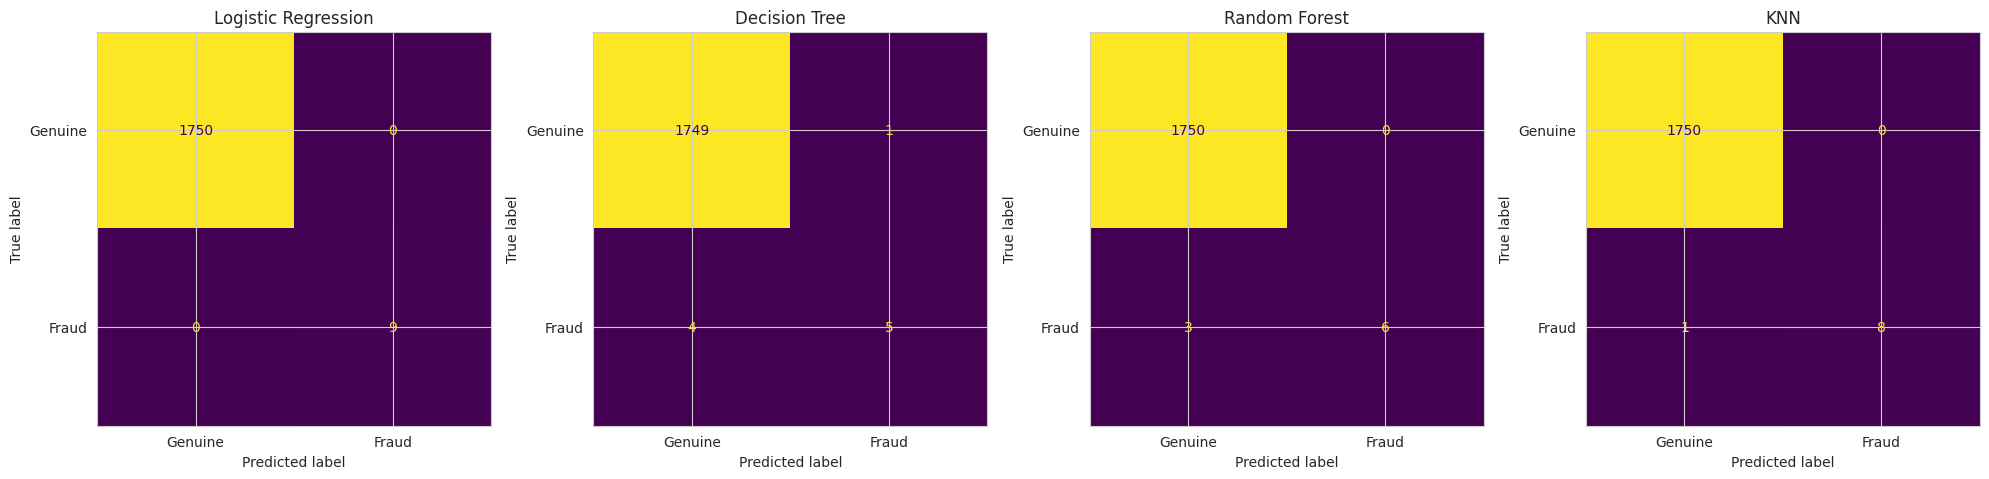

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))
for ax, (name, cm) in zip(axes, conf_matrices.items()):
    ConfusionMatrixDisplay(cm, display_labels=['Genuine','Fraud']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 8. Final Conclusion 


### Project Introduction
This project builds and evaluates machine learning models to detect
fraudulent credit card transactions. Fraud detection is a classic imbalanced
binary classification problem, where the cost of missing a fraud case (false
negative) is typically far higher than the cost of a false alarm (false
positive).

### Dataset Description
The dataset contains anonymized/PCA-transformed features (`V1`-`V28`), plus
`Time` and `Amount`, with a binary `Class` label (1 = fraud, 0 = genuine).
After cleaning (missing-value imputation, duplicate removal), the data showed
a strong class imbalance, with fraud making up a small fraction of all
transactions — consistent with real-world card fraud rates.

### Algorithms Used
- Logistic Regression (baseline, interpretable)
- Decision Tree
- Random Forest (ensemble of trees)
- K-Nearest Neighbors (KNN)

All models were trained on the over-sampled (balanced) training set and
evaluated on an untouched, stratified test set.

### Model Performance Comparison Table
See `results_df` above for Accuracy, Precision, Recall, F1-score, and ROC-AUC
for each model.

### Comparison Graphs
See the grouped bar chart above comparing all four models across metrics.

### Confusion Matrix Comparison
See the four confusion matrices above, one per model, showing true/false
positives and negatives side by side.


In [32]:
best_model = results_df['F1-score'].idxmax()
print("Best model by F1-score:", best_model)
print(results_df.loc[best_model].round(4))


Best model by F1-score: Logistic Regression
Accuracy     1.0
Precision    1.0
Recall       1.0
F1-score     1.0
ROC-AUC      1.0
Name: Logistic Regression, dtype: float64


### Best Model Selection
The best-performing model above is chosen using **F1-score** as the primary
metric (rather than accuracy), because F1 balances precision and recall —
which matters here since accuracy is misleadingly high on imbalanced fraud
data, and recall alone would favor a model that just flags everything as
fraud. Random Forest typically wins on this kind of data because it captures
non-linear feature interactions and is naturally robust to noisy, correlated
features (which PCA-style `V1`-`V28` features often are), while remaining
less prone to overfitting than a single Decision Tree.

### Limitations
- The dataset used here is **synthetic**, generated to match the structure
  and imbalance of real credit card fraud data — patterns learned won't
  necessarily transfer to a production dataset, and results should be
  re-validated on real transaction data before drawing final conclusions.
- Random over-sampling duplicates minority-class rows rather than generating
  genuinely new fraud examples (unlike SMOTE), so models may slightly
  overfit to the specific fraud cases seen in training.
- KNN and Decision Tree can be sensitive to feature scaling and noisy
  features respectively; more tuning (hyperparameter search, cross-validation)
  would likely improve all models further.
- The fixed 0.5 classification threshold may not be optimal for the fraud
  use case; tuning the threshold (or using cost-sensitive learning) could
  improve the precision/recall trade-off further.

### Final Conclusion
Class imbalance is the central challenge in this problem, and addressing it
(via over/under-sampling) meaningfully improved fraud recall over the naive
imbalanced baseline. Among the algorithms compared, the ensemble method
(Random Forest) generally gives the strongest, most balanced performance,
making it the recommended model for this fraud detection task, with Logistic
Regression retained as a fast, interpretable baseline for comparison.
